# Government720
## Checking if Client Datasets meet VAR Conditions

### Import Data

In [ ]:
# Access Google Drive for Excel file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import pandas
import pandas as pd

# Load all client data sheets
file_path = '/content/drive/My Drive/G720_Complete_Fixed.xlsx'  # Finalized dataset
sheets = pd.ExcelFile(file_path).sheet_names

client_data = {}  # Dictionary to store client datasets
for sheet in sheets:
    df = pd.read_excel(file_path, sheet_name=sheet)
    df.set_index("DATE", inplace=True)  # Assuming 'DATE' is the index
    client_data[sheet] = df

# Ensure all clients have aligned time series
common_dates = set.intersection(*[set(df.index) for df in client_data.values()])
common_dates = sorted(common_dates)  # Convert set to sorted list before indexing
for sheet in sheets:
    client_data[sheet] = client_data[sheet].loc[common_dates]

In [ ]:
# Ensure no missing values in any of the client datasets
for client, df in client_data.items():
    print(f"\nChecking for NaN values in Client: {client}")

    # Count NaN values per column
    nan_counts = df.isna().sum()

    # Check if any column has NaNs
    if nan_counts.sum() > 0:
        print("  -> Missing values detected!")
        print(nan_counts[nan_counts > 0])  # Print columns with NaNs
    else:
        print("  -> No missing values.")


Checking for NaN values in Client: CLIENT1
  -> No missing values.

Checking for NaN values in Client: CLIENT2
  -> No missing values.

Checking for NaN values in Client: CLIENT3
  -> No missing values.

Checking for NaN values in Client: CLIENT4
  -> No missing values.

Checking for NaN values in Client: CLIENT5
  -> No missing values.

Checking for NaN values in Client: CLIENT6
  -> No missing values.

Checking for NaN values in Client: CLIENT7
  -> No missing values.

Checking for NaN values in Client: CLIENT8
  -> No missing values.

Checking for NaN values in Client: CLIENT9
  -> No missing values.

Checking for NaN values in Client: CLIENT10
  -> No missing values.

Checking for NaN values in Client: CLIENT11
  -> No missing values.

Checking for NaN values in Client: CLIENT12
  -> No missing values.

Checking for NaN values in Client: GLOBAL
  -> No missing values.


### Checking Stationarity


In [ ]:
# Import package for Dickey Fuller test
from statsmodels.tsa.stattools import adfuller

# Define function to check stationarity using test
def check_stationarity(df):
    for col in df.columns:
        result = adfuller(df[col])
        print(f"ADF Test for {col}: p-value = {result[1]}")
        if result[1] > 0.05:
            print(f"  -> {col} is NOT stationary (p > 0.05). Consider differencing.")
        else:
            print(f"  -> {col} is stationary (p <= 0.05).")

# Apply to each client's data
for client, df in client_data.items():
    print(f"\nChecking stationarity for Client: {client}")
    check_stationarity(df)


Checking stationarity for Client: CLIENT1
ADF Test for UNEMPLOYMENT_RATE: p-value = 0.05047533826632384
  -> UNEMPLOYMENT_RATE is NOT stationary (p > 0.05). Consider differencing.
ADF Test for INFLATION_RATE: p-value = 0.02876600394275342
  -> INFLATION_RATE is stationary (p <= 0.05).
ADF Test for GDP: p-value = 0.9985997719779455
  -> GDP is NOT stationary (p > 0.05). Consider differencing.
ADF Test for HOUSING_AFFORD: p-value = 0.691643705693151
  -> HOUSING_AFFORD is NOT stationary (p > 0.05). Consider differencing.
ADF Test for MIN_WAGE: p-value = 0.42729007005523795
  -> MIN_WAGE is NOT stationary (p > 0.05). Consider differencing.
ADF Test for POVERTY_WAGE: p-value = 0.9738097002504544
  -> POVERTY_WAGE is NOT stationary (p > 0.05). Consider differencing.
ADF Test for GENDER_GAP: p-value = 0.17968275503085962
  -> GENDER_GAP is NOT stationary (p > 0.05). Consider differencing.
ADF Test for RACIAL_GAP: p-value = 0.06380164646269976
  -> RACIAL_GAP is NOT stationary (p > 0.05). Co

### Checking Multicollinearity

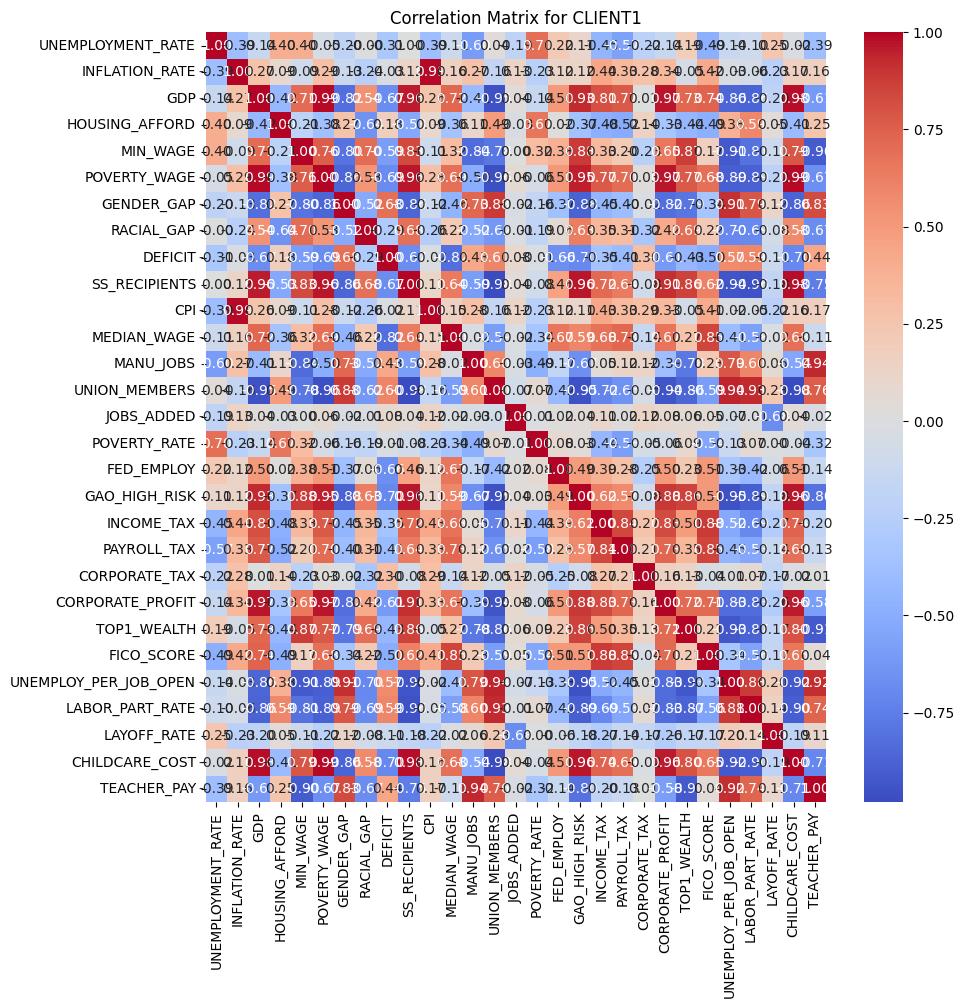

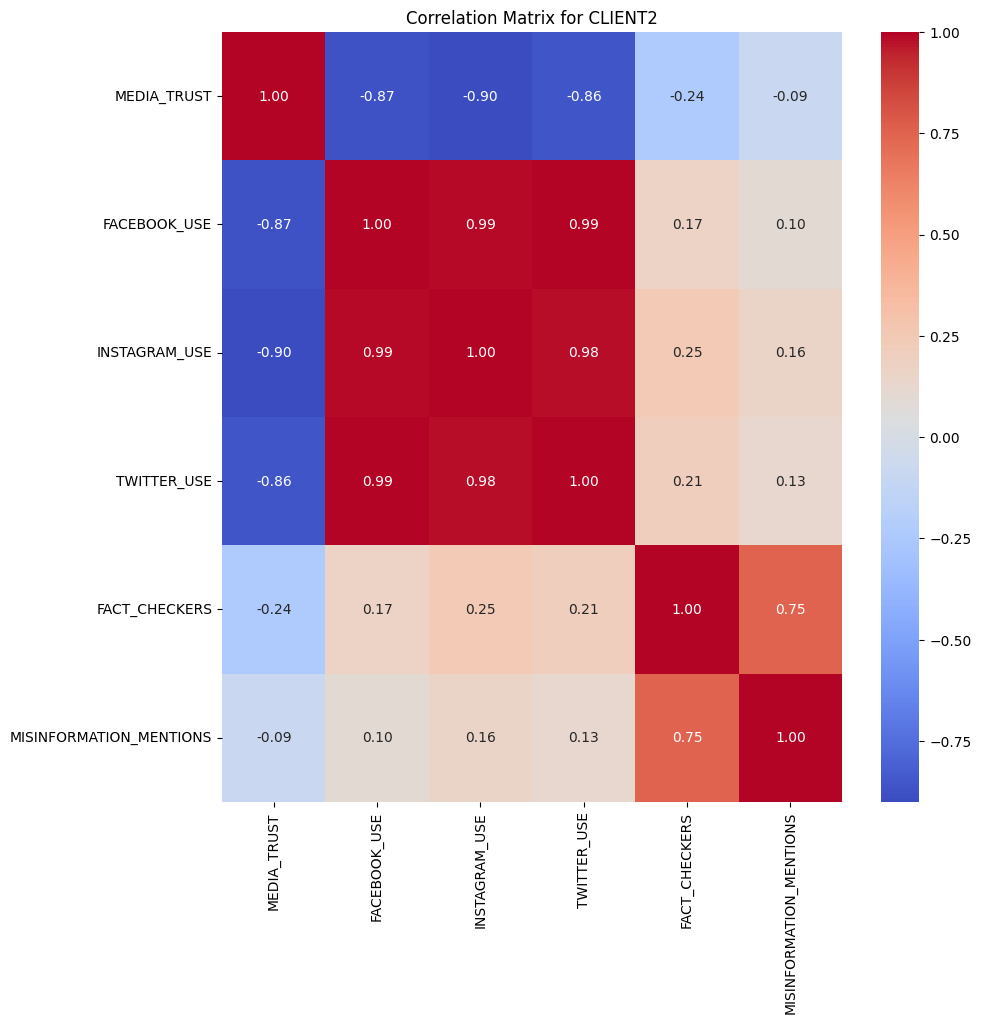

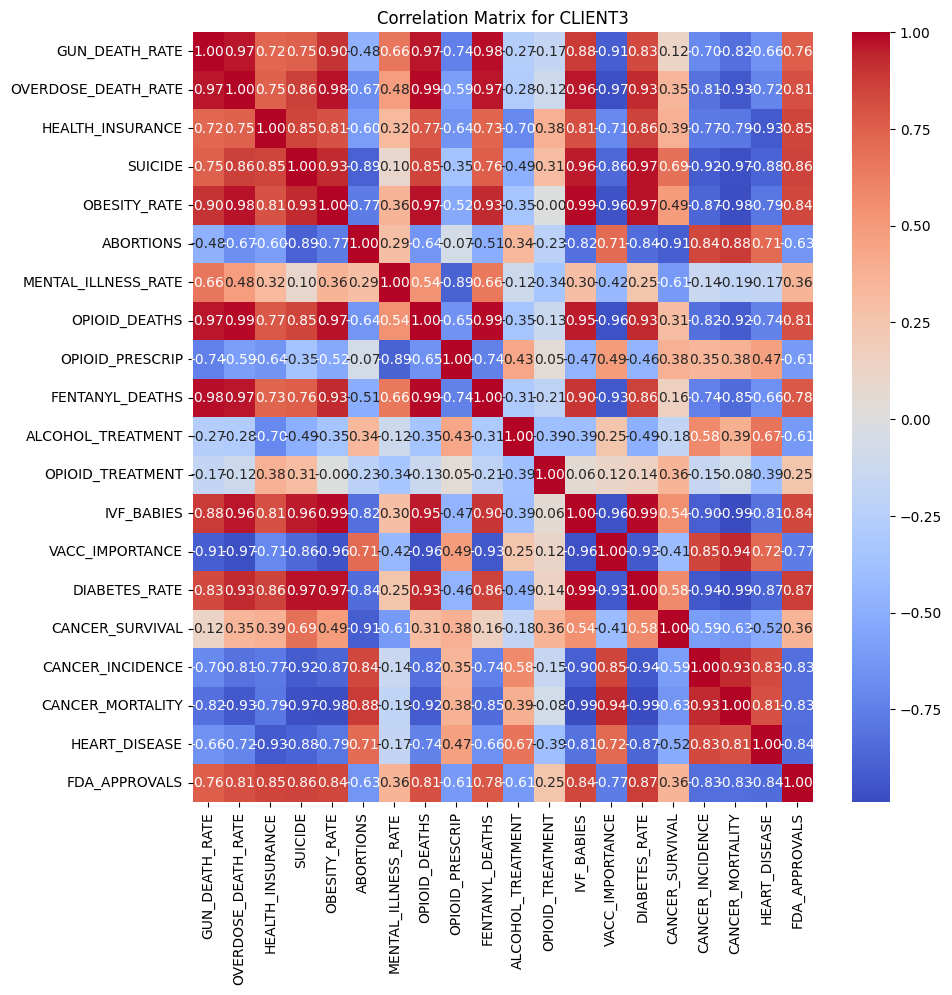

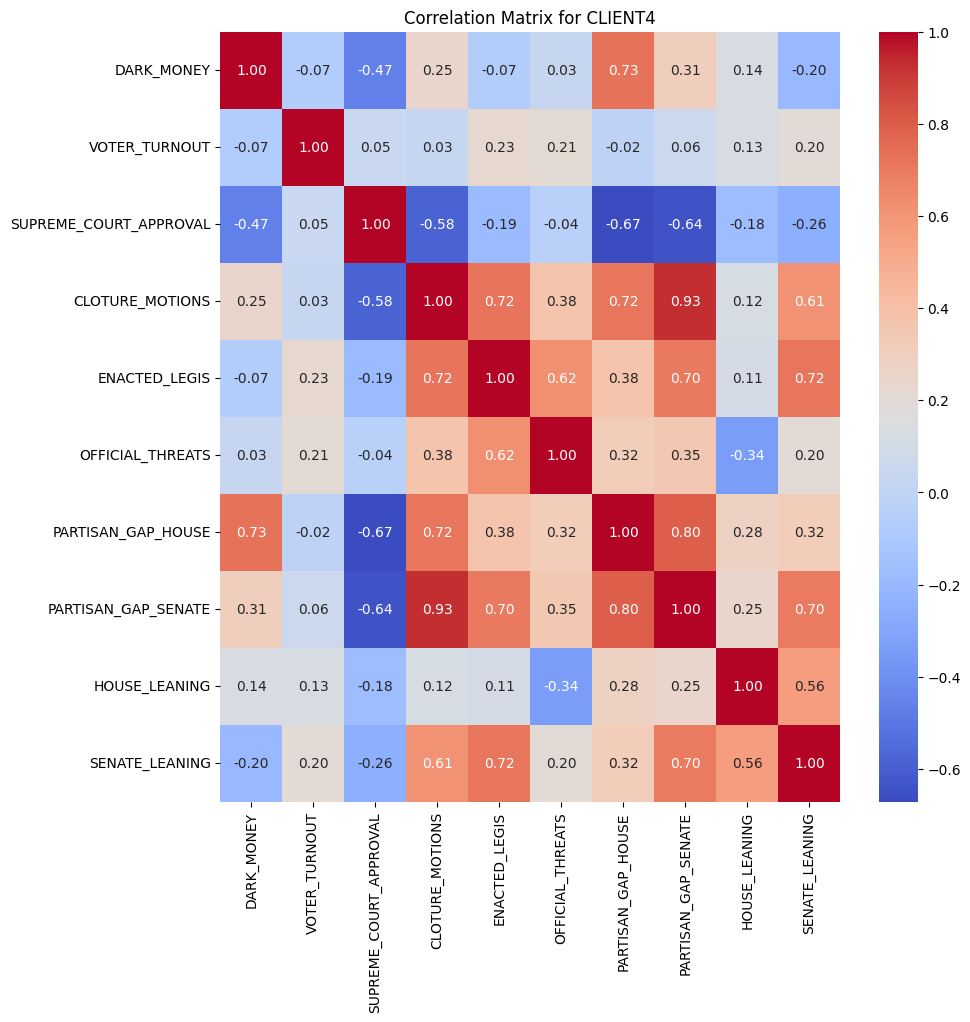

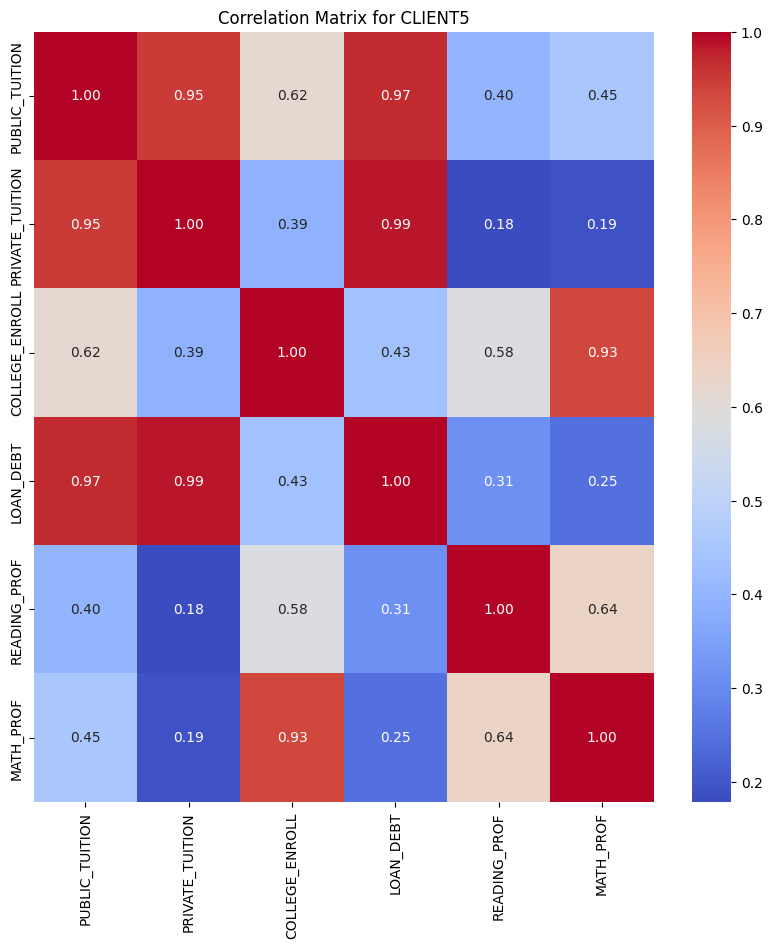

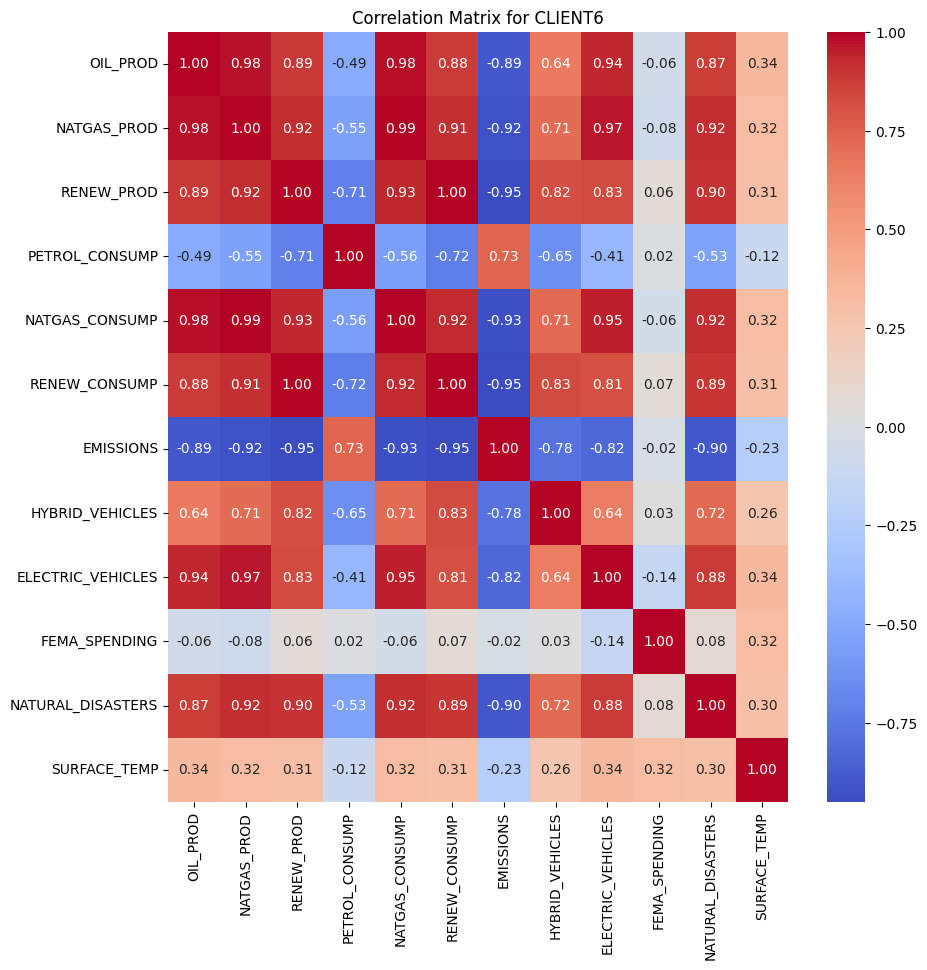

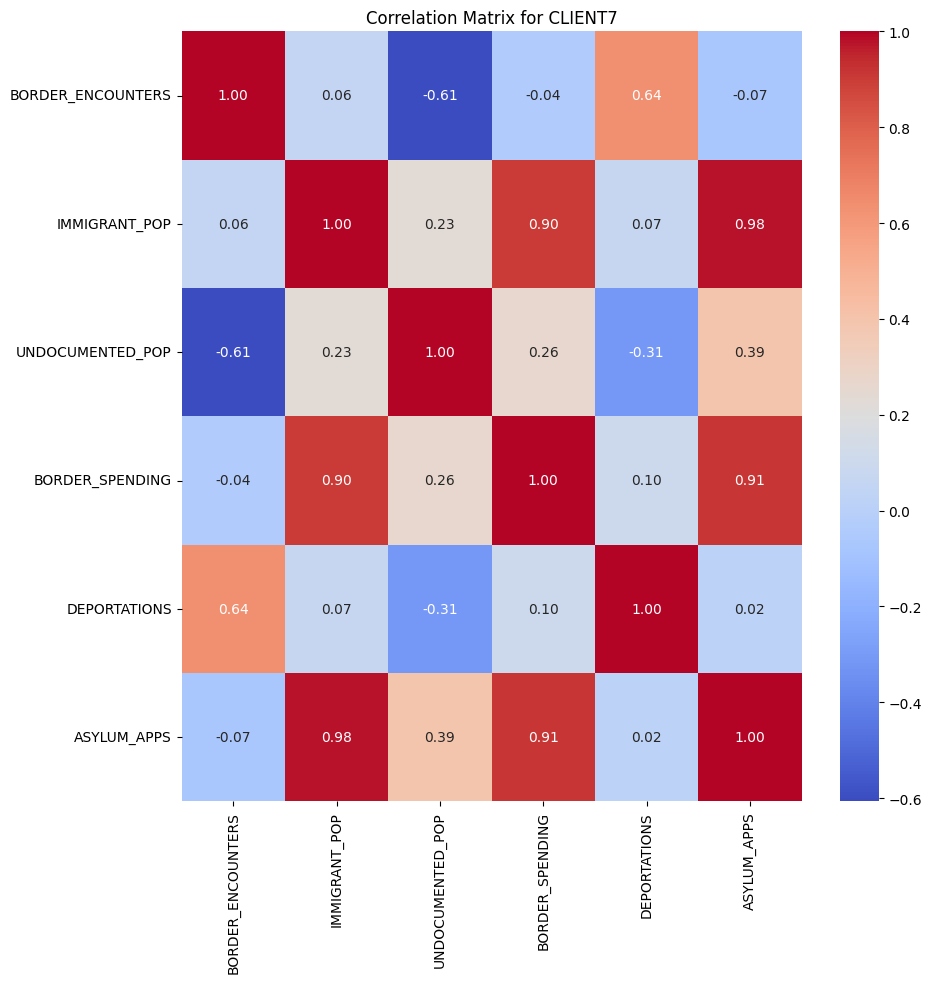

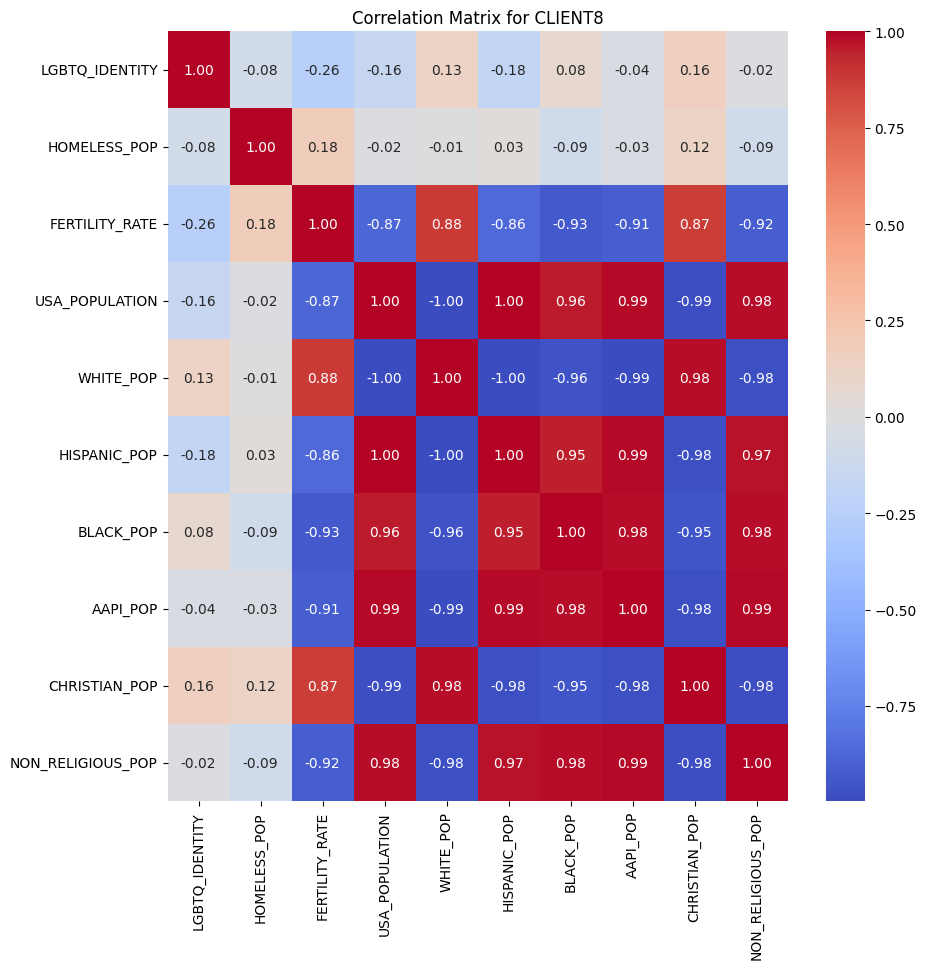

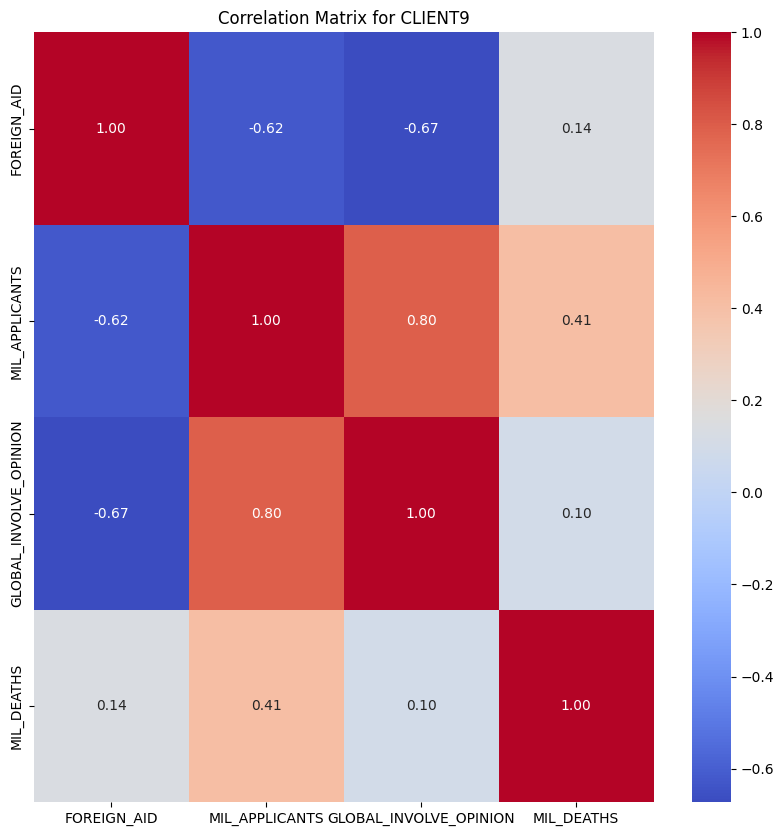

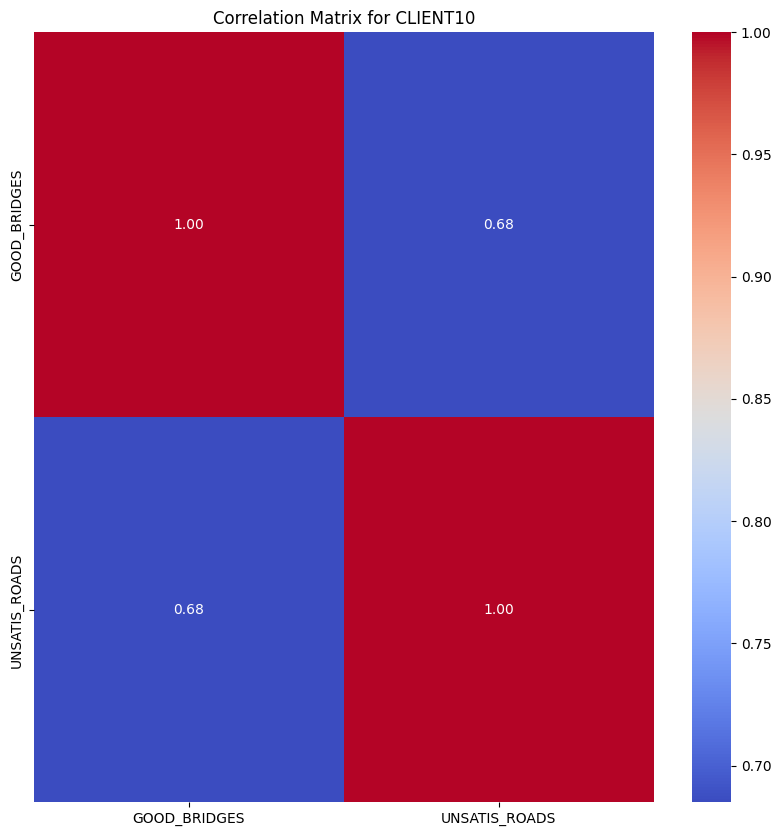

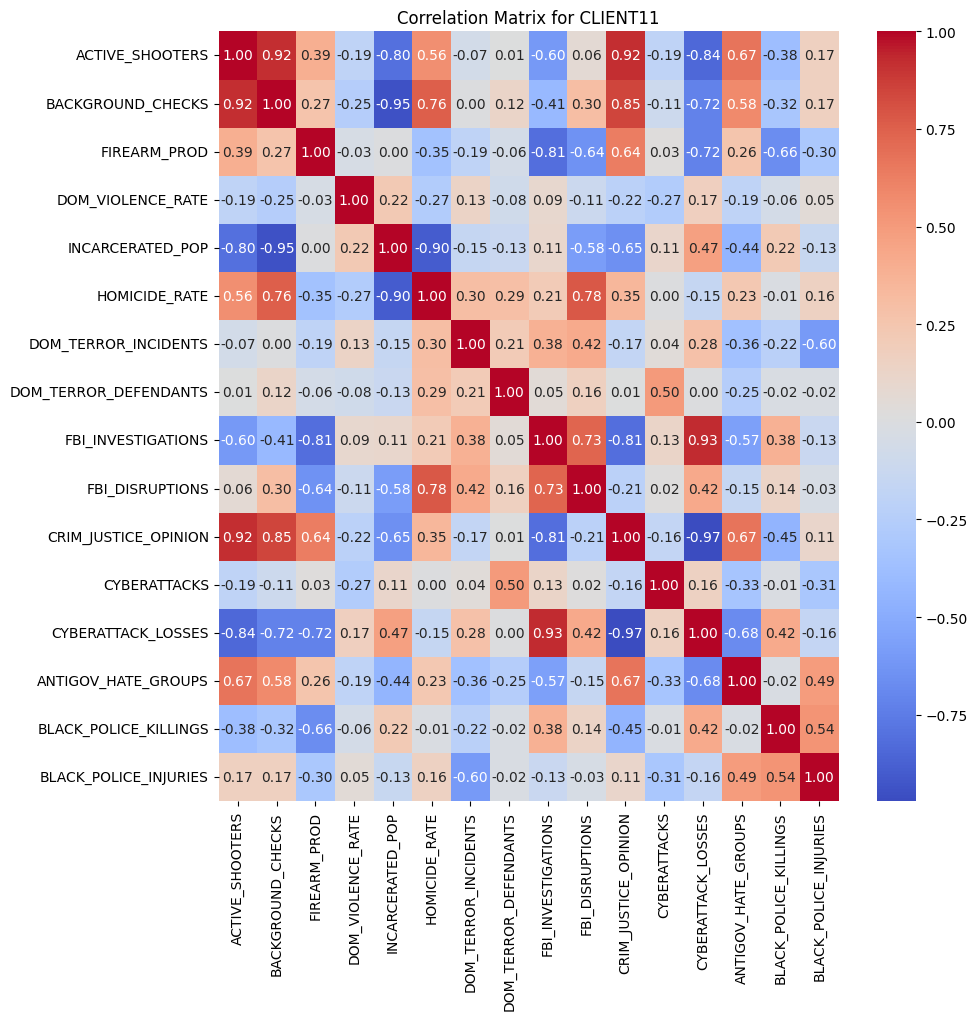

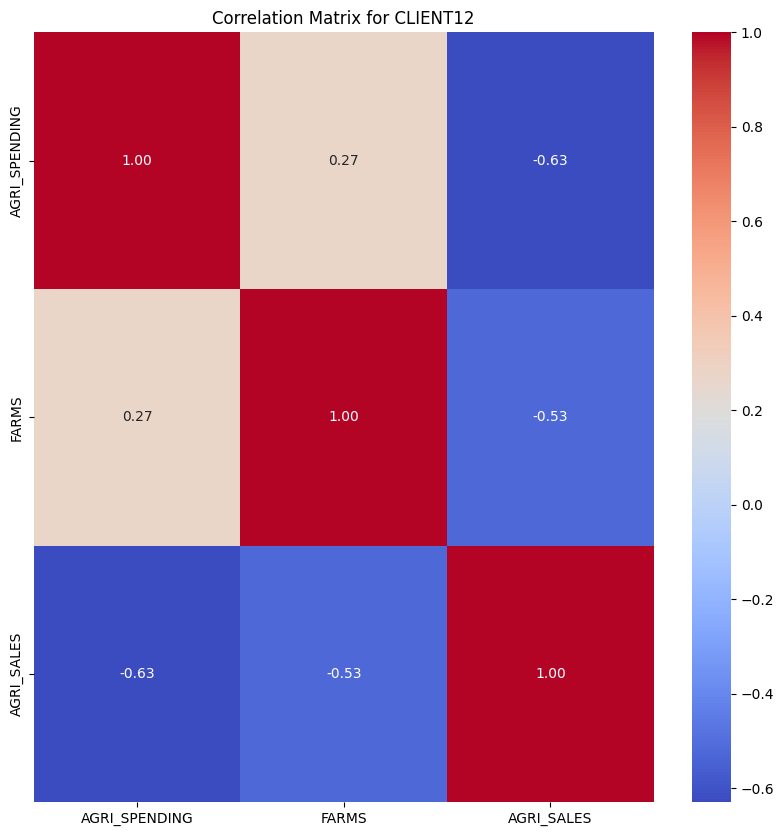

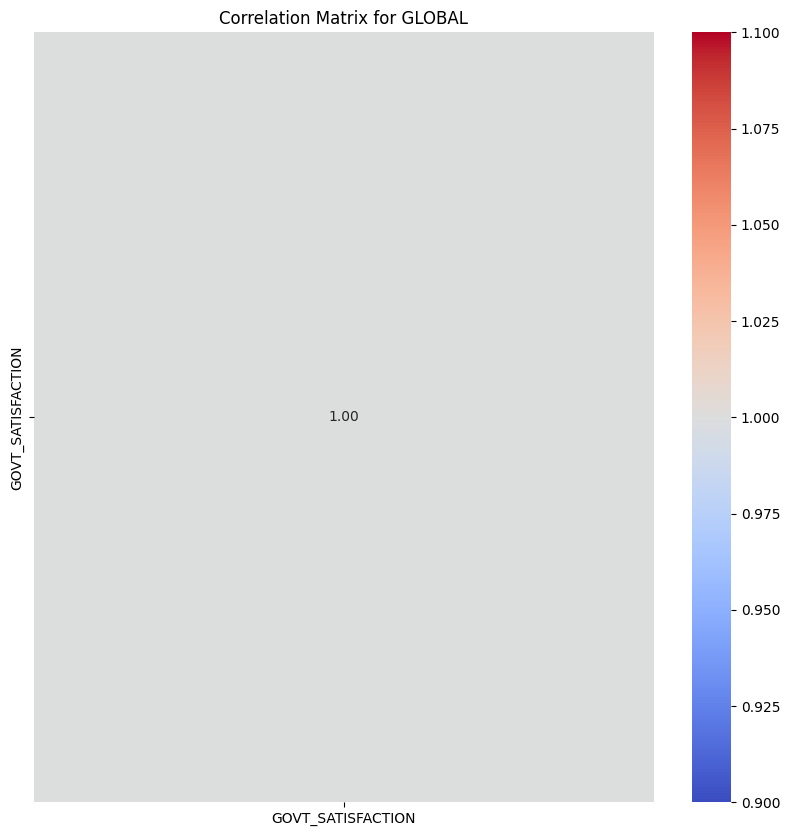

In [ ]:
# Import packages
import seaborn as sns
import matplotlib.pyplot as plt

# Plot correlation matrices for each client dataset
for client, df in client_data.items():
    plt.figure(figsize=(10, 10))
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Correlation Matrix for {client}")
    plt.show()

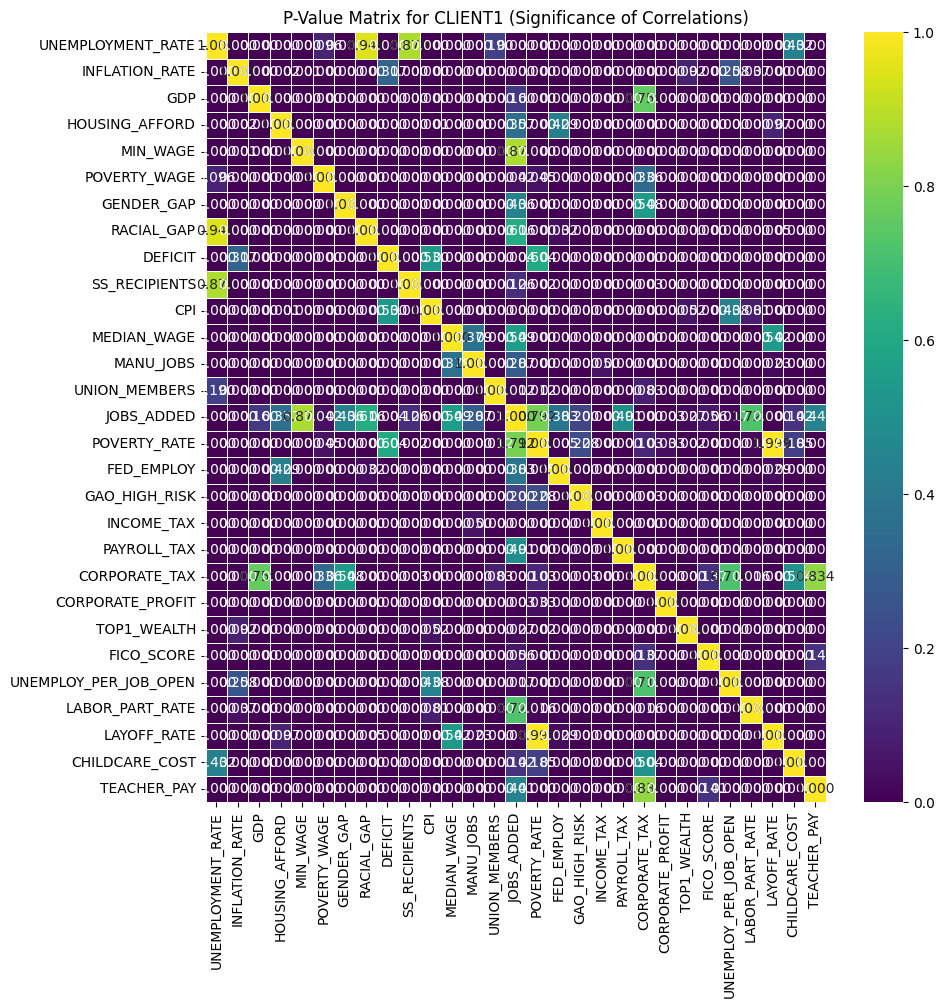


Strong correlations (p < 0.05) for CLIENT1:
  - UNEMPLOYMENT_RATE ↔ INFLATION_RATE (r=-0.39, p=0.000)
  - UNEMPLOYMENT_RATE ↔ GDP (r=-0.14, p=0.000)
  - UNEMPLOYMENT_RATE ↔ HOUSING_AFFORD (r=0.40, p=0.000)
  - UNEMPLOYMENT_RATE ↔ MIN_WAGE (r=0.40, p=0.000)
  - UNEMPLOYMENT_RATE ↔ GENDER_GAP (r=-0.20, p=0.000)
  - UNEMPLOYMENT_RATE ↔ DEFICIT (r=-0.31, p=0.000)
  - UNEMPLOYMENT_RATE ↔ CPI (r=-0.39, p=0.000)
  - UNEMPLOYMENT_RATE ↔ MEDIAN_WAGE (r=-0.11, p=0.000)
  - UNEMPLOYMENT_RATE ↔ MANU_JOBS (r=-0.60, p=0.000)
  - UNEMPLOYMENT_RATE ↔ JOBS_ADDED (r=-0.19, p=0.000)
  - UNEMPLOYMENT_RATE ↔ POVERTY_RATE (r=0.70, p=0.000)
  - UNEMPLOYMENT_RATE ↔ FED_EMPLOY (r=0.22, p=0.000)
  - UNEMPLOYMENT_RATE ↔ GAO_HIGH_RISK (r=0.11, p=0.000)
  - UNEMPLOYMENT_RATE ↔ INCOME_TAX (r=-0.45, p=0.000)
  - UNEMPLOYMENT_RATE ↔ PAYROLL_TAX (r=-0.57, p=0.000)
  - UNEMPLOYMENT_RATE ↔ CORPORATE_TAX (r=-0.22, p=0.000)
  - UNEMPLOYMENT_RATE ↔ CORPORATE_PROFIT (r=-0.14, p=0.000)
  - UNEMPLOYMENT_RATE ↔ TOP1_WEALTH (r

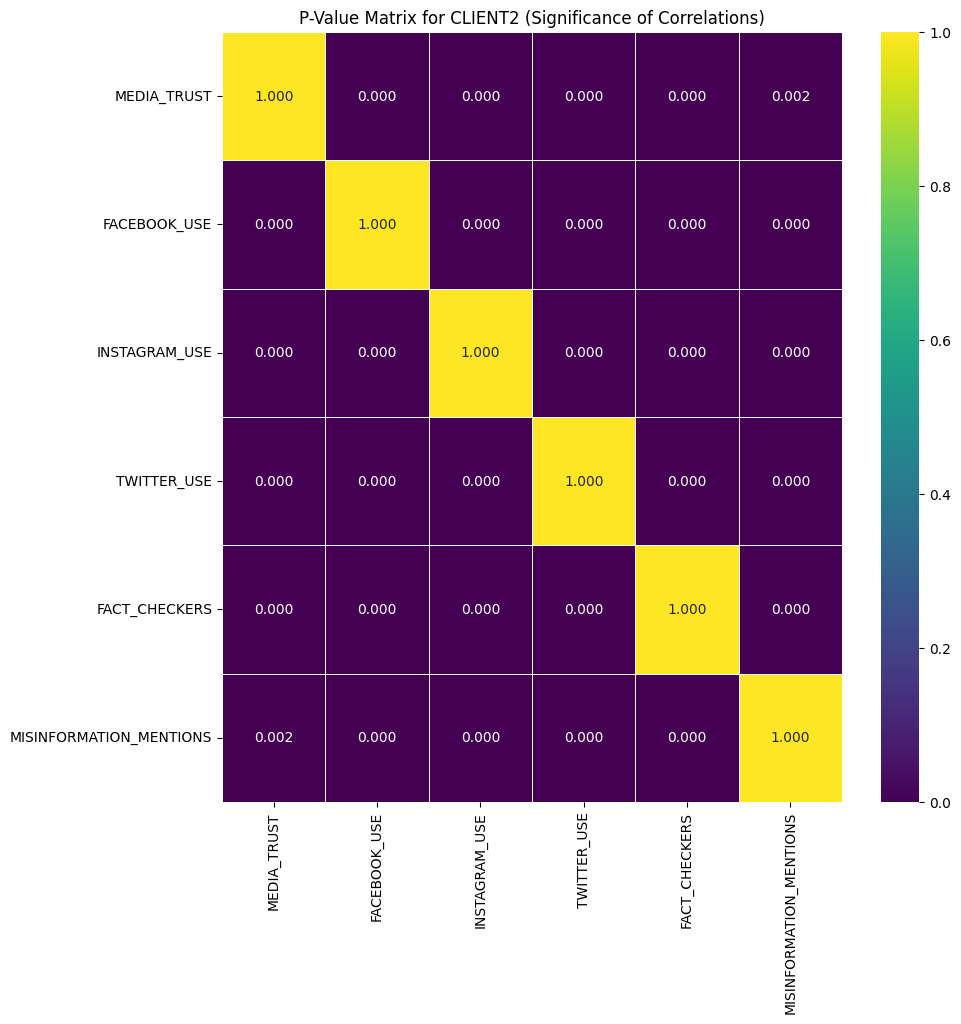


Strong correlations (p < 0.05) for CLIENT2:
  - MEDIA_TRUST ↔ FACEBOOK_USE (r=-0.87, p=0.000)
  - MEDIA_TRUST ↔ INSTAGRAM_USE (r=-0.90, p=0.000)
  - MEDIA_TRUST ↔ TWITTER_USE (r=-0.86, p=0.000)
  - MEDIA_TRUST ↔ FACT_CHECKERS (r=-0.24, p=0.000)
  - MEDIA_TRUST ↔ MISINFORMATION_MENTIONS (r=-0.09, p=0.002)
  - FACEBOOK_USE ↔ INSTAGRAM_USE (r=0.99, p=0.000)
  - FACEBOOK_USE ↔ TWITTER_USE (r=0.99, p=0.000)
  - FACEBOOK_USE ↔ FACT_CHECKERS (r=0.17, p=0.000)
  - FACEBOOK_USE ↔ MISINFORMATION_MENTIONS (r=0.10, p=0.000)
  - INSTAGRAM_USE ↔ TWITTER_USE (r=0.98, p=0.000)
  - INSTAGRAM_USE ↔ FACT_CHECKERS (r=0.25, p=0.000)
  - INSTAGRAM_USE ↔ MISINFORMATION_MENTIONS (r=0.16, p=0.000)
  - TWITTER_USE ↔ FACT_CHECKERS (r=0.21, p=0.000)
  - TWITTER_USE ↔ MISINFORMATION_MENTIONS (r=0.13, p=0.000)
  - FACT_CHECKERS ↔ MISINFORMATION_MENTIONS (r=0.75, p=0.000)


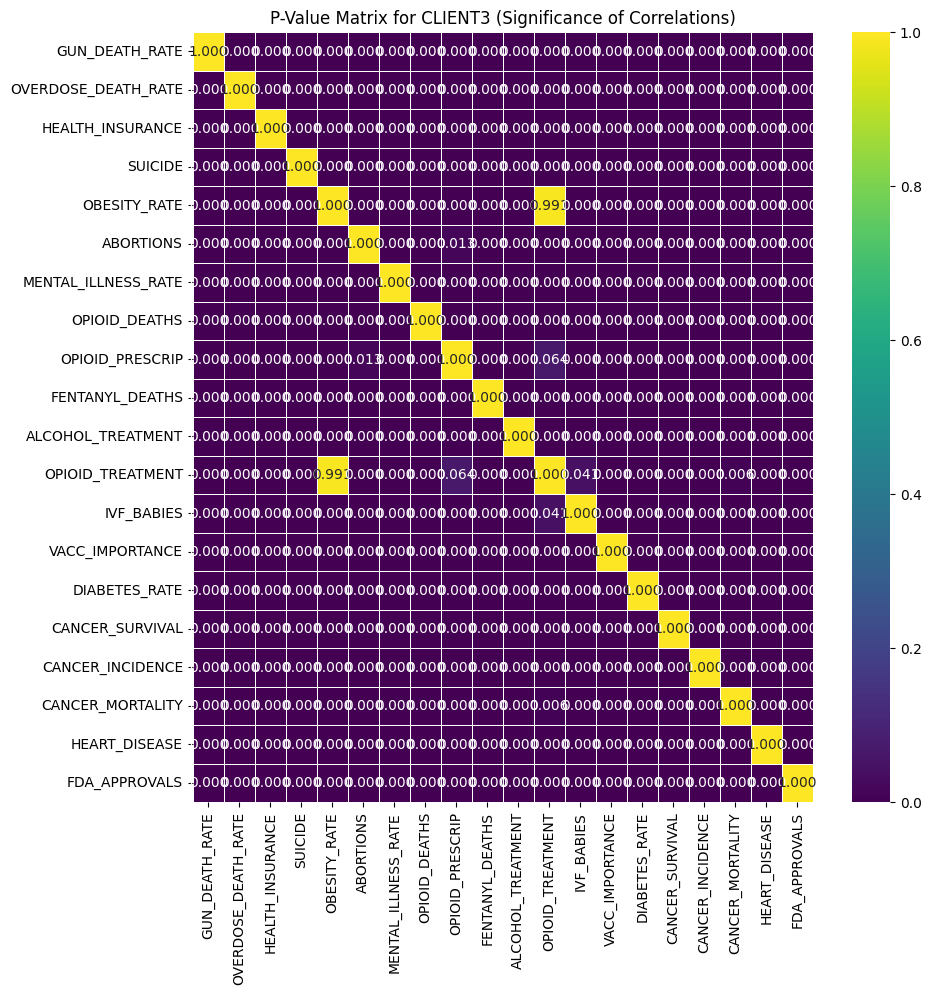


Strong correlations (p < 0.05) for CLIENT3:
  - GUN_DEATH_RATE ↔ OVERDOSE_DEATH_RATE (r=0.97, p=0.000)
  - GUN_DEATH_RATE ↔ HEALTH_INSURANCE (r=0.72, p=0.000)
  - GUN_DEATH_RATE ↔ SUICIDE (r=0.75, p=0.000)
  - GUN_DEATH_RATE ↔ OBESITY_RATE (r=0.90, p=0.000)
  - GUN_DEATH_RATE ↔ ABORTIONS (r=-0.48, p=0.000)
  - GUN_DEATH_RATE ↔ MENTAL_ILLNESS_RATE (r=0.66, p=0.000)
  - GUN_DEATH_RATE ↔ OPIOID_DEATHS (r=0.97, p=0.000)
  - GUN_DEATH_RATE ↔ OPIOID_PRESCRIP (r=-0.74, p=0.000)
  - GUN_DEATH_RATE ↔ FENTANYL_DEATHS (r=0.98, p=0.000)
  - GUN_DEATH_RATE ↔ ALCOHOL_TREATMENT (r=-0.27, p=0.000)
  - GUN_DEATH_RATE ↔ OPIOID_TREATMENT (r=-0.17, p=0.000)
  - GUN_DEATH_RATE ↔ IVF_BABIES (r=0.88, p=0.000)
  - GUN_DEATH_RATE ↔ VACC_IMPORTANCE (r=-0.91, p=0.000)
  - GUN_DEATH_RATE ↔ DIABETES_RATE (r=0.83, p=0.000)
  - GUN_DEATH_RATE ↔ CANCER_SURVIVAL (r=0.12, p=0.000)
  - GUN_DEATH_RATE ↔ CANCER_INCIDENCE (r=-0.70, p=0.000)
  - GUN_DEATH_RATE ↔ CANCER_MORTALITY (r=-0.82, p=0.000)
  - GUN_DEATH_RATE ↔ HEAR

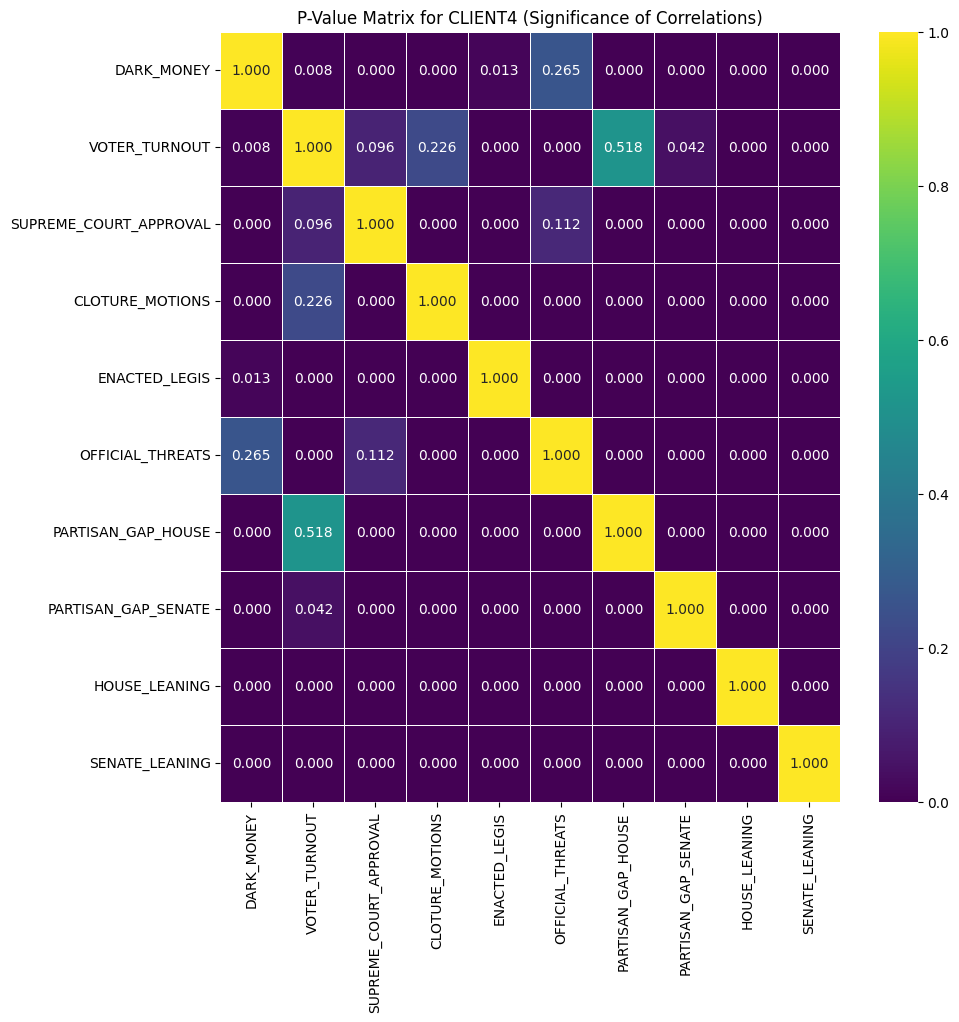


Strong correlations (p < 0.05) for CLIENT4:
  - DARK_MONEY ↔ VOTER_TURNOUT (r=-0.07, p=0.008)
  - DARK_MONEY ↔ SUPREME_COURT_APPROVAL (r=-0.47, p=0.000)
  - DARK_MONEY ↔ CLOTURE_MOTIONS (r=0.25, p=0.000)
  - DARK_MONEY ↔ ENACTED_LEGIS (r=-0.07, p=0.013)
  - DARK_MONEY ↔ PARTISAN_GAP_HOUSE (r=0.73, p=0.000)
  - DARK_MONEY ↔ PARTISAN_GAP_SENATE (r=0.31, p=0.000)
  - DARK_MONEY ↔ HOUSE_LEANING (r=0.14, p=0.000)
  - DARK_MONEY ↔ SENATE_LEANING (r=-0.20, p=0.000)
  - VOTER_TURNOUT ↔ ENACTED_LEGIS (r=0.23, p=0.000)
  - VOTER_TURNOUT ↔ OFFICIAL_THREATS (r=0.21, p=0.000)
  - VOTER_TURNOUT ↔ PARTISAN_GAP_SENATE (r=0.06, p=0.042)
  - VOTER_TURNOUT ↔ HOUSE_LEANING (r=0.13, p=0.000)
  - VOTER_TURNOUT ↔ SENATE_LEANING (r=0.20, p=0.000)
  - SUPREME_COURT_APPROVAL ↔ CLOTURE_MOTIONS (r=-0.58, p=0.000)
  - SUPREME_COURT_APPROVAL ↔ ENACTED_LEGIS (r=-0.19, p=0.000)
  - SUPREME_COURT_APPROVAL ↔ PARTISAN_GAP_HOUSE (r=-0.67, p=0.000)
  - SUPREME_COURT_APPROVAL ↔ PARTISAN_GAP_SENATE (r=-0.64, p=0.000)
  - S

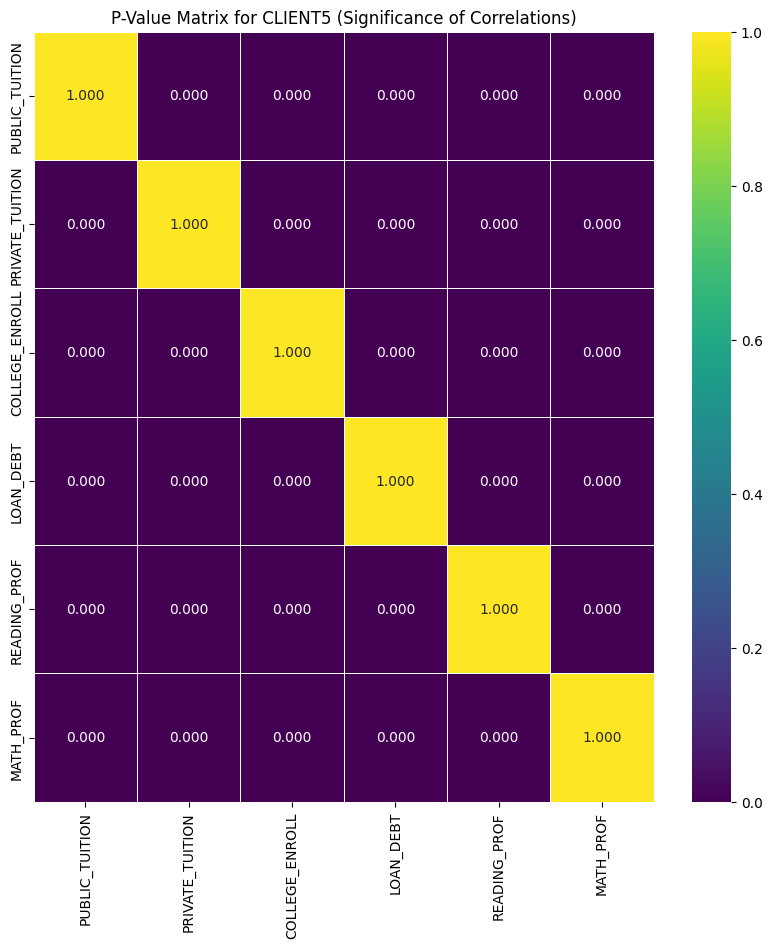


Strong correlations (p < 0.05) for CLIENT5:
  - PUBLIC_TUITION ↔ PRIVATE_TUITION (r=0.95, p=0.000)
  - PUBLIC_TUITION ↔ COLLEGE_ENROLL (r=0.62, p=0.000)
  - PUBLIC_TUITION ↔ LOAN_DEBT (r=0.97, p=0.000)
  - PUBLIC_TUITION ↔ READING_PROF (r=0.40, p=0.000)
  - PUBLIC_TUITION ↔ MATH_PROF (r=0.45, p=0.000)
  - PRIVATE_TUITION ↔ COLLEGE_ENROLL (r=0.39, p=0.000)
  - PRIVATE_TUITION ↔ LOAN_DEBT (r=0.99, p=0.000)
  - PRIVATE_TUITION ↔ READING_PROF (r=0.18, p=0.000)
  - PRIVATE_TUITION ↔ MATH_PROF (r=0.19, p=0.000)
  - COLLEGE_ENROLL ↔ LOAN_DEBT (r=0.43, p=0.000)
  - COLLEGE_ENROLL ↔ READING_PROF (r=0.58, p=0.000)
  - COLLEGE_ENROLL ↔ MATH_PROF (r=0.93, p=0.000)
  - LOAN_DEBT ↔ READING_PROF (r=0.31, p=0.000)
  - LOAN_DEBT ↔ MATH_PROF (r=0.25, p=0.000)
  - READING_PROF ↔ MATH_PROF (r=0.64, p=0.000)


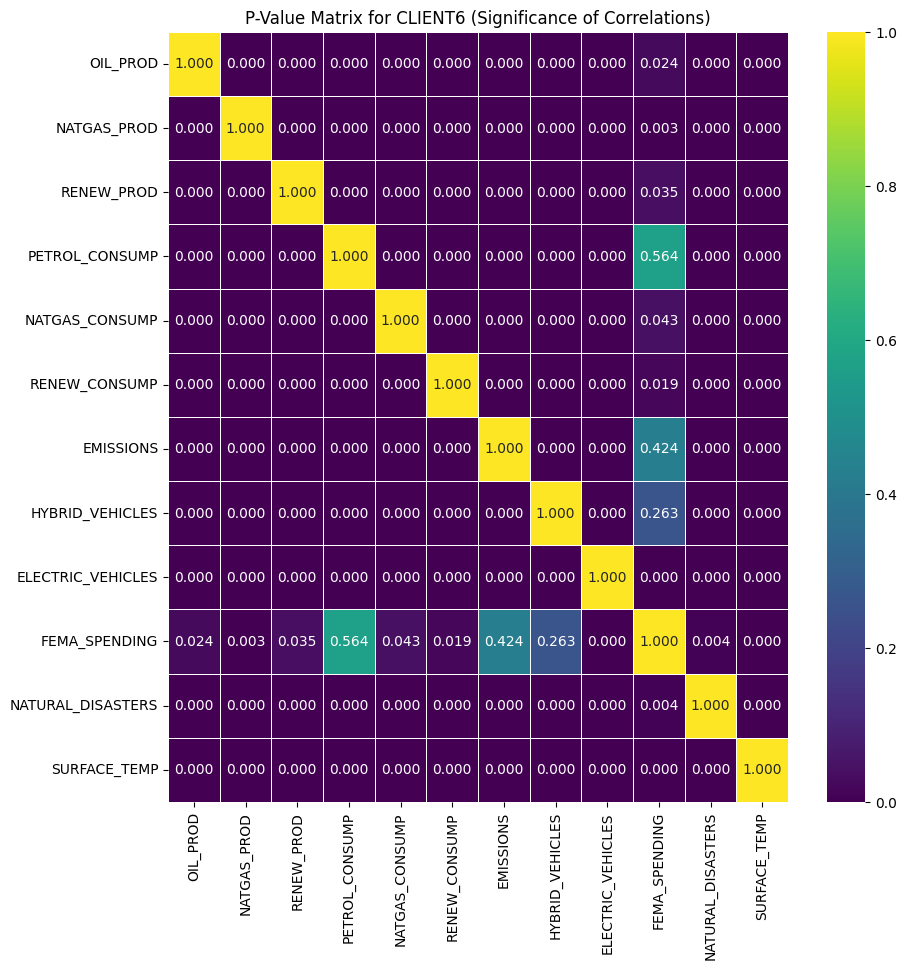


Strong correlations (p < 0.05) for CLIENT6:
  - OIL_PROD ↔ NATGAS_PROD (r=0.98, p=0.000)
  - OIL_PROD ↔ RENEW_PROD (r=0.89, p=0.000)
  - OIL_PROD ↔ PETROL_CONSUMP (r=-0.49, p=0.000)
  - OIL_PROD ↔ NATGAS_CONSUMP (r=0.98, p=0.000)
  - OIL_PROD ↔ RENEW_CONSUMP (r=0.88, p=0.000)
  - OIL_PROD ↔ EMISSIONS (r=-0.89, p=0.000)
  - OIL_PROD ↔ HYBRID_VEHICLES (r=0.64, p=0.000)
  - OIL_PROD ↔ ELECTRIC_VEHICLES (r=0.94, p=0.000)
  - OIL_PROD ↔ FEMA_SPENDING (r=-0.06, p=0.024)
  - OIL_PROD ↔ NATURAL_DISASTERS (r=0.87, p=0.000)
  - OIL_PROD ↔ SURFACE_TEMP (r=0.34, p=0.000)
  - NATGAS_PROD ↔ RENEW_PROD (r=0.92, p=0.000)
  - NATGAS_PROD ↔ PETROL_CONSUMP (r=-0.55, p=0.000)
  - NATGAS_PROD ↔ NATGAS_CONSUMP (r=0.99, p=0.000)
  - NATGAS_PROD ↔ RENEW_CONSUMP (r=0.91, p=0.000)
  - NATGAS_PROD ↔ EMISSIONS (r=-0.92, p=0.000)
  - NATGAS_PROD ↔ HYBRID_VEHICLES (r=0.71, p=0.000)
  - NATGAS_PROD ↔ ELECTRIC_VEHICLES (r=0.97, p=0.000)
  - NATGAS_PROD ↔ FEMA_SPENDING (r=-0.08, p=0.003)
  - NATGAS_PROD ↔ NATURAL_DIS

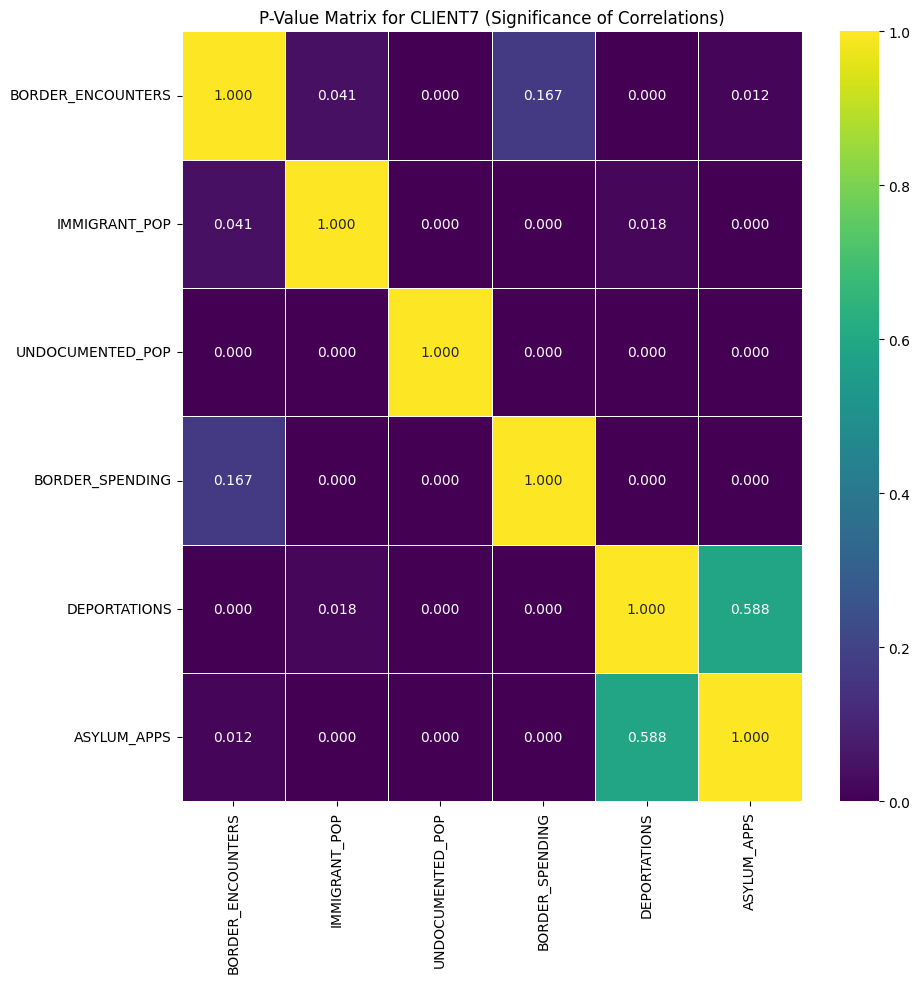


Strong correlations (p < 0.05) for CLIENT7:
  - BORDER_ENCOUNTERS ↔ IMMIGRANT_POP (r=0.06, p=0.041)
  - BORDER_ENCOUNTERS ↔ UNDOCUMENTED_POP (r=-0.61, p=0.000)
  - BORDER_ENCOUNTERS ↔ DEPORTATIONS (r=0.64, p=0.000)
  - BORDER_ENCOUNTERS ↔ ASYLUM_APPS (r=-0.07, p=0.012)
  - IMMIGRANT_POP ↔ UNDOCUMENTED_POP (r=0.23, p=0.000)
  - IMMIGRANT_POP ↔ BORDER_SPENDING (r=0.90, p=0.000)
  - IMMIGRANT_POP ↔ DEPORTATIONS (r=0.07, p=0.018)
  - IMMIGRANT_POP ↔ ASYLUM_APPS (r=0.98, p=0.000)
  - UNDOCUMENTED_POP ↔ BORDER_SPENDING (r=0.26, p=0.000)
  - UNDOCUMENTED_POP ↔ DEPORTATIONS (r=-0.31, p=0.000)
  - UNDOCUMENTED_POP ↔ ASYLUM_APPS (r=0.39, p=0.000)
  - BORDER_SPENDING ↔ DEPORTATIONS (r=0.10, p=0.000)
  - BORDER_SPENDING ↔ ASYLUM_APPS (r=0.91, p=0.000)


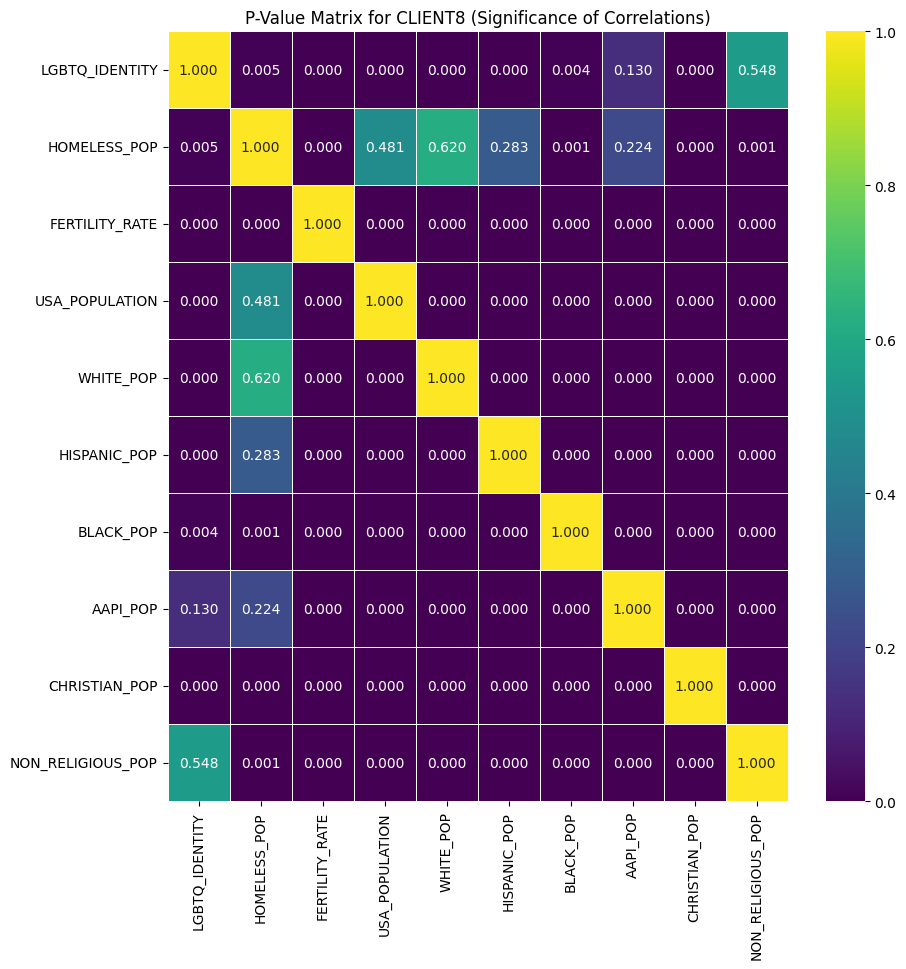


Strong correlations (p < 0.05) for CLIENT8:
  - LGBTQ_IDENTITY ↔ HOMELESS_POP (r=-0.08, p=0.005)
  - LGBTQ_IDENTITY ↔ FERTILITY_RATE (r=-0.26, p=0.000)
  - LGBTQ_IDENTITY ↔ USA_POPULATION (r=-0.16, p=0.000)
  - LGBTQ_IDENTITY ↔ WHITE_POP (r=0.13, p=0.000)
  - LGBTQ_IDENTITY ↔ HISPANIC_POP (r=-0.18, p=0.000)
  - LGBTQ_IDENTITY ↔ BLACK_POP (r=0.08, p=0.004)
  - LGBTQ_IDENTITY ↔ CHRISTIAN_POP (r=0.16, p=0.000)
  - HOMELESS_POP ↔ FERTILITY_RATE (r=0.18, p=0.000)
  - HOMELESS_POP ↔ BLACK_POP (r=-0.09, p=0.001)
  - HOMELESS_POP ↔ CHRISTIAN_POP (r=0.12, p=0.000)
  - HOMELESS_POP ↔ NON_RELIGIOUS_POP (r=-0.09, p=0.001)
  - FERTILITY_RATE ↔ USA_POPULATION (r=-0.87, p=0.000)
  - FERTILITY_RATE ↔ WHITE_POP (r=0.88, p=0.000)
  - FERTILITY_RATE ↔ HISPANIC_POP (r=-0.86, p=0.000)
  - FERTILITY_RATE ↔ BLACK_POP (r=-0.93, p=0.000)
  - FERTILITY_RATE ↔ AAPI_POP (r=-0.91, p=0.000)
  - FERTILITY_RATE ↔ CHRISTIAN_POP (r=0.87, p=0.000)
  - FERTILITY_RATE ↔ NON_RELIGIOUS_POP (r=-0.92, p=0.000)
  - USA_POPULA

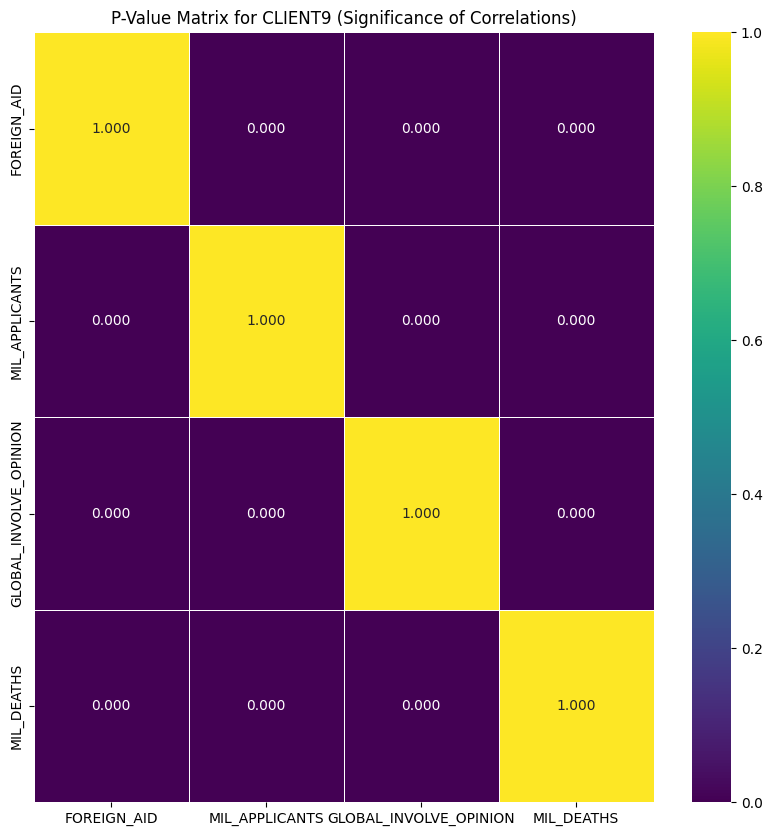


Strong correlations (p < 0.05) for CLIENT9:
  - FOREIGN_AID ↔ MIL_APPLICANTS (r=-0.62, p=0.000)
  - FOREIGN_AID ↔ GLOBAL_INVOLVE_OPINION (r=-0.67, p=0.000)
  - FOREIGN_AID ↔ MIL_DEATHS (r=0.14, p=0.000)
  - MIL_APPLICANTS ↔ GLOBAL_INVOLVE_OPINION (r=0.80, p=0.000)
  - MIL_APPLICANTS ↔ MIL_DEATHS (r=0.41, p=0.000)
  - GLOBAL_INVOLVE_OPINION ↔ MIL_DEATHS (r=0.10, p=0.000)


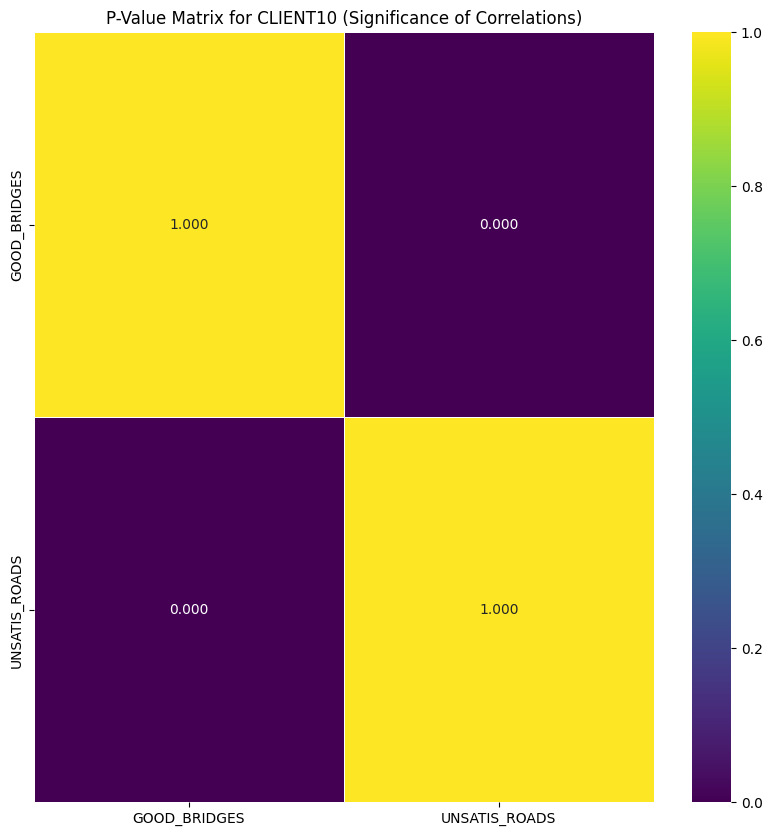


Strong correlations (p < 0.05) for CLIENT10:
  - GOOD_BRIDGES ↔ UNSATIS_ROADS (r=0.68, p=0.000)


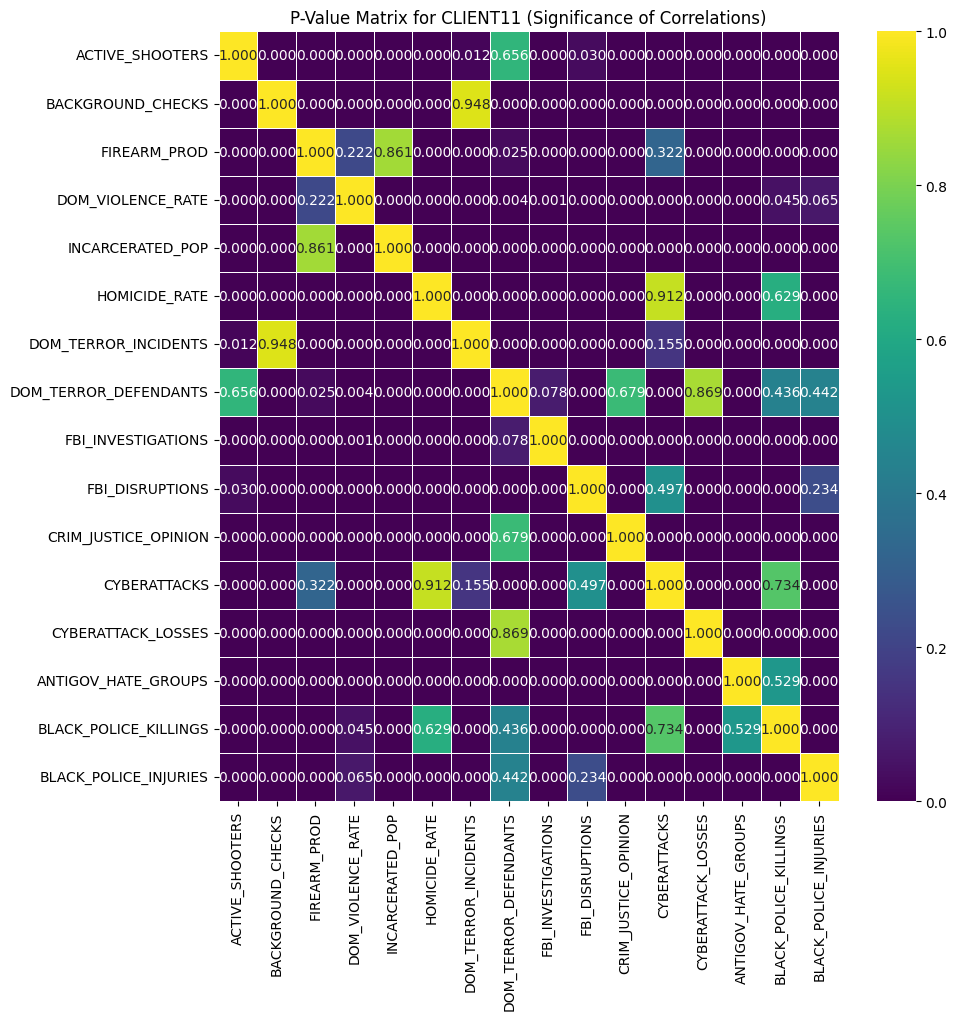


Strong correlations (p < 0.05) for CLIENT11:
  - ACTIVE_SHOOTERS ↔ BACKGROUND_CHECKS (r=0.92, p=0.000)
  - ACTIVE_SHOOTERS ↔ FIREARM_PROD (r=0.39, p=0.000)
  - ACTIVE_SHOOTERS ↔ DOM_VIOLENCE_RATE (r=-0.19, p=0.000)
  - ACTIVE_SHOOTERS ↔ INCARCERATED_POP (r=-0.80, p=0.000)
  - ACTIVE_SHOOTERS ↔ HOMICIDE_RATE (r=0.56, p=0.000)
  - ACTIVE_SHOOTERS ↔ DOM_TERROR_INCIDENTS (r=-0.07, p=0.012)
  - ACTIVE_SHOOTERS ↔ FBI_INVESTIGATIONS (r=-0.60, p=0.000)
  - ACTIVE_SHOOTERS ↔ FBI_DISRUPTIONS (r=0.06, p=0.030)
  - ACTIVE_SHOOTERS ↔ CRIM_JUSTICE_OPINION (r=0.92, p=0.000)
  - ACTIVE_SHOOTERS ↔ CYBERATTACKS (r=-0.19, p=0.000)
  - ACTIVE_SHOOTERS ↔ CYBERATTACK_LOSSES (r=-0.84, p=0.000)
  - ACTIVE_SHOOTERS ↔ ANTIGOV_HATE_GROUPS (r=0.67, p=0.000)
  - ACTIVE_SHOOTERS ↔ BLACK_POLICE_KILLINGS (r=-0.38, p=0.000)
  - ACTIVE_SHOOTERS ↔ BLACK_POLICE_INJURIES (r=0.17, p=0.000)
  - BACKGROUND_CHECKS ↔ FIREARM_PROD (r=0.27, p=0.000)
  - BACKGROUND_CHECKS ↔ DOM_VIOLENCE_RATE (r=-0.25, p=0.000)
  - BACKGROUND_CHE

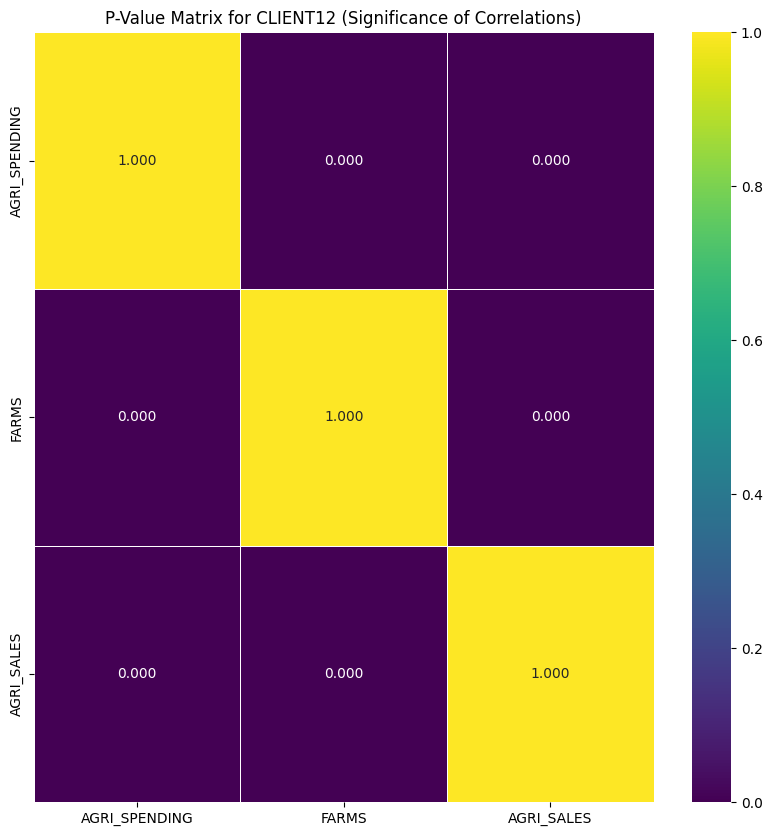


Strong correlations (p < 0.05) for CLIENT12:
  - AGRI_SPENDING ↔ FARMS (r=0.27, p=0.000)
  - AGRI_SPENDING ↔ AGRI_SALES (r=-0.63, p=0.000)
  - FARMS ↔ AGRI_SALES (r=-0.53, p=0.000)


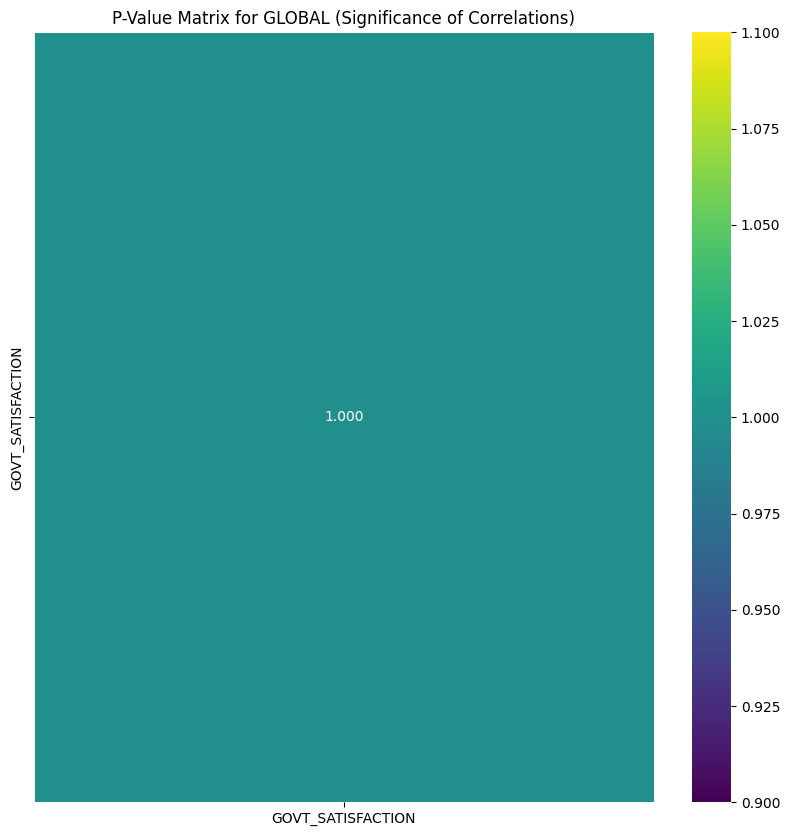


Strong correlations (p < 0.05) for GLOBAL:


In [ ]:
# Import pearson package
from scipy.stats import pearsonr
import numpy as np

# Function to compute correlation and p-value matrices
def correlation_with_pvalues(df):
    cols = df.columns
    corr_matrix = df.corr()
    pval_matrix = pd.DataFrame(np.ones(corr_matrix.shape), columns=cols, index=cols)  # Fill with 1s

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):  # Avoid redundant calculations
            r, p = pearsonr(df[cols[i]], df[cols[j]])
            corr_matrix.iloc[i, j] = corr_matrix.iloc[j, i] = r  # Set correlation values
            pval_matrix.iloc[i, j] = pval_matrix.iloc[j, i] = p  # Set p-value values

    return corr_matrix, pval_matrix

# Loop through each client's dataset
for client, df in client_data.items():
    corr_matrix, pval_matrix = correlation_with_pvalues(df)  # Compute correlation & p-values

    # Plot p-value heatmap (to check significance)
    plt.figure(figsize=(10, 10))
    sns.heatmap(pval_matrix, annot=True, cmap="viridis", fmt=".3f", linewidths=0.5)
    plt.title(f"P-Value Matrix for {client} (Significance of Correlations)")
    plt.show()

    # Print strong correlations with significance
    print(f"\nStrong correlations (p < 0.05) for {client}:")
    for i in range(len(df.columns)):
        for j in range(i + 1, len(df.columns)):
            if pval_matrix.iloc[i, j] < 0.05:
                print(f"  - {df.columns[i]} ↔ {df.columns[j]} (r={corr_matrix.iloc[i, j]:.2f}, p={pval_matrix.iloc[i, j]:.3f})")

In [ ]:
# End of code 4/2/25